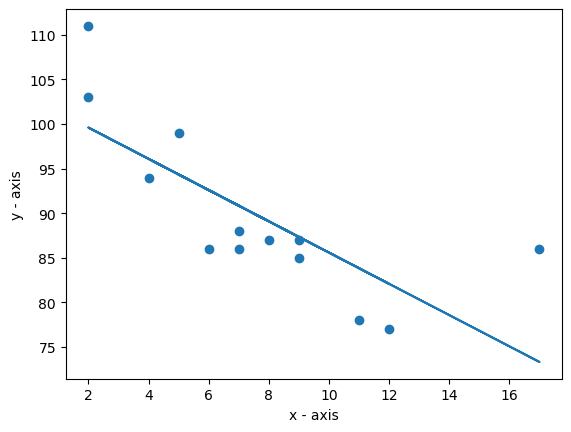

In [ ]:
#linear regression is a method to find the relationship between two variables. 
# It is used to find the line of best fit for a set of data points. 
# The line of best fit is the line that minimizes the distance between the data points and the line. 
# The line of best fit can be used to make predictions about the data.

# We import scipy to use the linear regression function.
from scipy import stats
import matplotlib.pyplot as plt

# A basic example of linear regression

x = [5,7,8,7,2,17,2,9,4,11,12,9,6]
y = [99,86,87,88,111,86,103,87,94,78,77,85,86]

# Each (x, y) pair is one observation.
slope, intercept, r, p, std_err = stats.linregress(x, y)
# slope --> how steep the line is
# Intercept --> where the line crosses the y-axis
# r --> how well the line fits the data (correlation coefficient)
# p --> the probability that the slope is zero (no relationship between x and y)
# std_err --> the standard error of the estimate

# Basically under the hood, This solved using least square method.
# this minimizes the sum of the squared differences between the observed values and the values predicted.

def myfunc(x):
    return slope * x + intercept
# this creates a your regression equation (y = mx + b)

my_model = list(map(myfunc, x))
# this applies the regression equation to each x value to get the predicted y values.
plt.scatter(x, y)
plt.plot(x, my_model)
plt.xlabel('x - axis')
plt.ylabel('y - axis')
plt.show()


# why is this used ? 
# 1. predictions: we can use the regression equation to make predictions about y values for given x values.
# 2. understanding relationships: it helps us understand the relationship between two variables (x and y).
# 3. identifying trends: it can help us identify trends in the data and make informed decisions based on those trends.




In [1]:
# Independent Variables (Features)

import random
import numpy as np

random.seed(42)
np.random.seed(42)

n = 500

income = []
credit_score = []
loan_amount = []
debt_to_income_ratio = []
years_of_employment = []
past_defaults = []
expected_loss_amount = []

for _ in range(n):
    
    inc = round(random.uniform(2, 20), 2)  # income in lakhs
    cs = random.randint(500, 850)
    loan = round(random.uniform(2, 15), 2)
    dti = round(random.uniform(10, 60), 2)
    years_emp = random.randint(0, 15)
    defaults = random.randint(0, 4)
    
    # Economic logic-based expected loss formula
    # Positive impact
    loss = (
        loan * 4000 +
        dti * 1200 +
        defaults * 25000
    )
    
    # Negative impact
    loss -= (
        cs * 200 +
        inc * 5000 +
        years_emp * 1500
    )
    
    # Add random noise
    noise = random.uniform(-20000, 20000)
    loss += noise
    
    # Ensure loss is not negative
    loss = max(loss, 1000)
    
    income.append(inc)
    credit_score.append(cs)
    loan_amount.append(loan)
    debt_to_income_ratio.append(dti)
    years_of_employment.append(years_emp)
    past_defaults.append(defaults)
    expected_loss_amount.append(round(loss, 2))

In [2]:
import pandas as pd

df = pd.DataFrame({
    "income": income,
    "credit_score": credit_score,
    "loan_amount": loan_amount,
    "debt_to_income_ratio": debt_to_income_ratio,
    "years_of_employment": years_of_employment,
    "past_defaults": past_defaults,
    "expected_loss_amount": expected_loss_amount
})

In [3]:
import sklearn

In [ ]:
x = df.drop("expected_loss_amount", axis = 1) 
# this drops the target variable or dependent variable 
# from the dataframe and keeps only the independent variables or features.
# stores independent variables in x and dependent variable in y.
# (income, credit_score, loan_amount, debt_to_income_ratio, years_of_employment, past_defaults)

y = df["expected_loss_amount"]
# keeps only the target variable or dependent variable in the dataframe.

# ------------------------------------------------------------------------------------------------

# Now using train split 80% for training and 20% for testing.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
# this splits the data into training and testing sets.
# test_size = 0.2 means 20% of the data will be used for testing and 80% for training.
# random_state = 42 is used to ensure that the split is reproducible 
# (you will get the same split every time you run the code).
# ------------------------------------------------------------------------------------------------
# import linear regression model from sklearn and fit the model to the training data.
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
# Now the model has learned coefficients.

# ------------------------------------------------------------------------------------------------

# now checking coefficients and intercept of the model.
# basically the coefficents tell how something changes with respect to the change in the independent variable.
coefficients = pd.DataFrame(model.coef_, x.columns, columns = ["Coefficient"])
print(coefficients)
print("Intercept:", model.intercept_)

# ------------------------------------------------------------------------------------------------

# Its time to predict the values fot the test set and check the performance of the model.
y_pred = model.predict(x_test)
# this uses the trained model to predict the target variable for the test set.


# ------------------------------------------------------------------------------------------------

# Now we will evaluate the performance of the model using metircs R2 score and mean absolure error.

from sklearn.metrics import r2_score, mean_absolute_error
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("R2 Score:", r2)
print("Mean Absolute Error:", mae)
print(df.corr())

# ------------------------------------------------------------------------------------------------




                      Coefficient
income                -406.413471
credit_score           -12.677983
loan_amount            196.761252
debt_to_income_ratio   112.537703
years_of_employment    -81.220471
past_defaults         1395.489665
Intercept: 7988.5214723992185
R2 Score: 0.20037377846035165
Mean Absolute Error: 3951.7768303568755
                        income  credit_score  loan_amount  \
income                1.000000     -0.010540     0.018445   
credit_score         -0.010540      1.000000     0.061490   
loan_amount           0.018445      0.061490     1.000000   
debt_to_income_ratio  0.012947     -0.026635    -0.067644   
years_of_employment  -0.036354      0.033321    -0.004730   
past_defaults        -0.005963     -0.017388    -0.042096   
expected_loss_amount -0.275036     -0.161920     0.061614   

                      debt_to_income_ratio  years_of_employment  \
income                            0.012947            -0.036354   
credit_score                     -0.026

ValueError: continuous is not supported

In [14]:
# Take input from user
inc = float(input("Enter income (in lakhs): "))
cs = int(input("Enter credit score: "))
loan = float(input("Enter loan amount (in lakhs): "))
dti = float(input("Enter debt-to-income ratio: "))
years_emp = int(input("Enter years of employment: "))
defaults = int(input("Enter number of past defaults: "))

import numpy as np

new_customer = np.array([[inc, cs, loan, dti, years_emp, defaults]])

predicted_loss = model.predict(new_customer)[0]

print("Predicted Expected Loss:", round(predicted_loss, 2))

if predicted_loss < 8000:
    risk = "🟢 Low Risk"
elif predicted_loss < 18000:
    risk = "🟡 Medium Risk"
else:
    risk = "🔴 High Risk"

print("Risk Category:", risk)

Predicted Expected Loss: -327708105.65
Risk Category: 🟢 Low Risk


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
